<a href="https://colab.research.google.com/github/Ashton94089/Actuarial-Practice/blob/main/04_python_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python for Actuaries Part 4
# Agenda
In this notebook, we cover:

* Introduction to Matplotlib
* Advanced visualizations
* Seaborn for advanced visualizations
* Characteristics of effective visualizations

# Introduction to Matplotlib and pyplot

`matplotlib.pyplot` is a key library in Python for data visualization. It offers a simple interface for creating 2D plots and is particularly useful for displaying data quickly and effectively. From simple line charts to complex visualizations, `pyplot` allows you to create a wide variety of plot types.

# Matplotlib and the inspiration from other tools
Matplotlib has drawn inspiration from various tools and concepts, including:
* Gnuplot: A traditional visualization tool that laid the foundation for many features in Matplotlib, particularly its straightforward plotting mechanisms.

* ggplot (R): Another significant source of inspiration for Matplotlib, especially for its layer-based structure, which allows users to build plots step-by-step.

Matplotlib is partly based on the Grammar of Graphics, a concept developed by Leland Wilkinson. It describes how graphical representations are organized into multiple layers: data, aesthetics (such as color or size), geometries (such as lines or points), and scales (e.g., axes). This system enables a flexible and systematic approach to data visualization.

# Basic mode of operation
To work with `matplotlib.pyplot`, you must first import the library. The basic syntax involves passing data to a plotting function, such as `plot()`, and then calling the `show()` function to display the plot:

In [ ]:
import matplotlib.pyplot as plt
# Example: Simple line graph
# x = [1, 2, 3, 4, 5]
# y = [2, 4, 6, 8, 10]
# plt.plot(x, y)  # Create a line plot
# plt.title("A simple line plot")  # Add plot title
# plt.xlabel("X-axis")  # X-axis label
# plt.ylabel("Y-axis")  # Y-axis label
# plt.show()  # Display the plot

# Elements of a Matplotlib figure
In `matplotlib`, a figure is the entire image or visualization you create. A figure can consist of various components, which are described below:

* **Figure**: The entire drawing or image you generate. A figure can contain multiple subplots.

* Axes: The area where the data is plotted. A figure can have one or more axes (subplots).

* **Title**: The title of the plot, which describes the diagram.

* **Labels**: Labels for the x- and y-axes that clarify the meaning of the axes.

* **Legend**: Explains the different data series within the plot.

* **Ticks**: The marks along the axes that represent specific values.

* **Subplots**: Multiple diagrams within a figure, arranged in a grid.

A **Matplotlib-figure** thus consists of several components that can be individually customized to create meaningful data visualizations.

Before we look at various types of charts, let us first manipulate the different elements of a figure using a very simple example.

To do this, we naturally need data first. We will simulate synthetic damage data:

In [ ]:
import pandas as pd
import numpy as np

# Parameters for the dataset
np.random.seed(42)
number_of_entries = 400 # Number of damage reports
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2023-12-31')
dates = pd.date_range(start=start_date, end=end_date, periods=number_of_entries)

# Generate synthetic data
contract_ids = np.random.randint(10000, 20000, number_of_entries)
amount_of_damage = np.random.normal(loc=10000, scale=3000, size=number_of_entries)
region = np.random.choice(['North', 'East', 'South', 'West'], number_of_entries)
claim_types = np.random.choice(['earthquake', 'flood', 'hurricane', 'wildfire'], number_of_entries)

# Limit the damage amount to positive values ​​and round to two decimal places
amount_of_damage = np.clip(amount_of_damage, 500, None)
amount_of_damage = np.round(amount_of_damage, 2)

# Create DataFrame
natural_damage_df = pd.DataFrame({
    'Date_of_loss': dates,
    'Contract_ID': contract_ids,
    'Amount_of_Damage': amount_of_damage,
    'Region': region,
    'Claim_Type': claim_types
})

# Display the first few lines of the dataset
# print(natural_damage_df.head())
natural_damage_df

,Date_of_loss,Contract_ID,Amount_of_Damage,Region,Claim_Type
0,2020-01-01 00:00:00.000000000,17270,15343.87,North,hurricane
1,2020-01-04 15:49:10.375939849,10860,7967.75,North,flood
2,2020-01-08 07:38:20.751879699,15390,5353.51,East,hurricane
3,2020-01-11 23:27:31.127819548,15191,8970.61,West,earthquake
4,2020-01-15 15:16:41.503759398,15734,10551.57,North,hurricane
...,...,...,...,...,...
395,2023-12-16 08:43:18.496240608,18311,12855.65,South,flood
396,2023-12-20 00:32:28.872180448,10830,6836.09,East,hurricane
397,2023-12-23 16:21:39.248120304,15177,7811.58,North,flood
398,2023-12-27 08:10:49.624060144,19561,5249.78,East,wildfire


We want to visualize the data at the monthly level, so we need to group and pivot:

In [ ]:
# Grouping by year and month and summing the claim amount
natural_damage_df['Month'] = natural_damage_df['Date_of_loss'].dt.to_period('M')
grouped_by_month = natural_damage_df.groupby(['Month','Region'])['Amount_of_Damage'].sum().reset_index()

# Pivoting the DataFrame to have regions as columns
pivot_df = grouped_by_month.pivot(index='Month', columns='Region', values='Amount_of_Damage').fillna(0)
pivot_df.head()

Region,East,North,South,West
Month,,,,
2020-01,21757.43,56277.43,14966.38,8970.61
2020-02,25306.10,8221.35,26173.24,10259.70
2020-03,21795.17,11573.83,48536.54,19561.10
2020-04,23224.69,6896.79,34423.75,39174.61
2020-05,9665.74,39100.91,16646.34,11340.67


And now, it's time to start drawing:

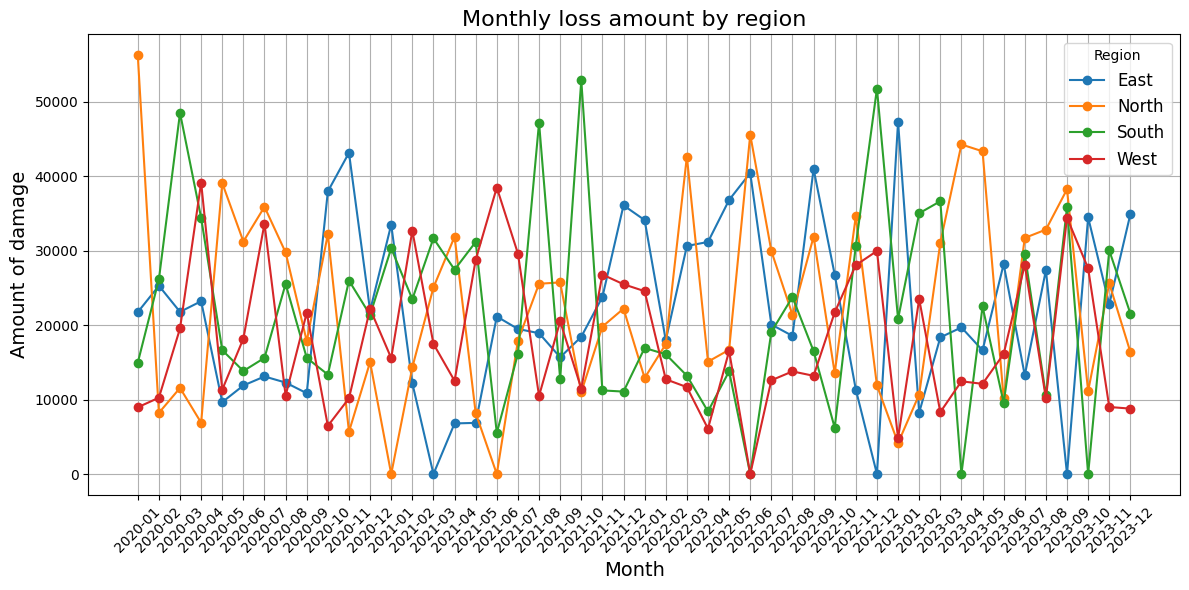

In [ ]:
# Create a visualization of damage amounts by region
plt.figure(figsize=(12, 6))

# Iterate through the columns of the pivoted DataFrame and plot each region
for region in pivot_df.columns:
  plt.plot(pivot_df.index.astype(str), pivot_df[region], marker='o', label=region)

# Adjust chart
plt.title('Monthly loss amount by region', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Amount of damage', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Region', fontsize=12)
plt.grid()
plt.tight_layout()

# Display the diagram
plt.show()

And now the same diagram again, but with a few small changes:

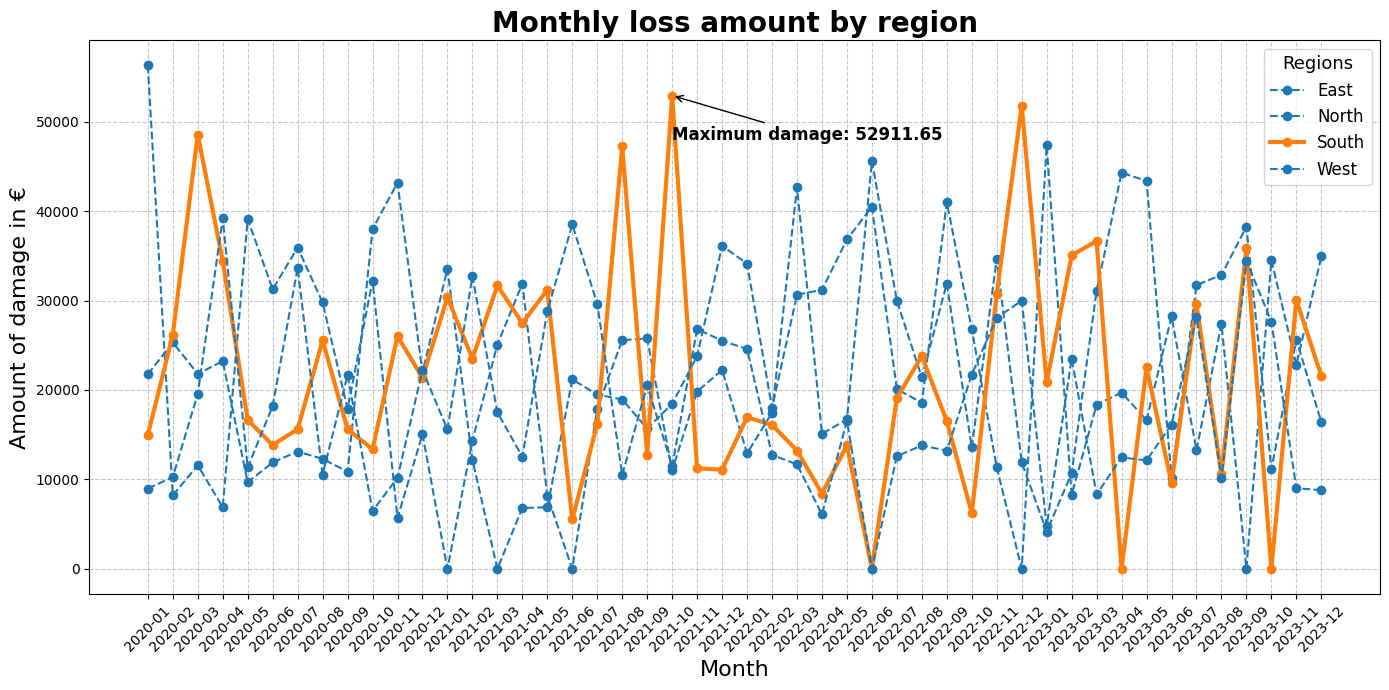

In [ ]:
# Create a visualization of damage amounts by region
plt.figure(figsize=(14, 7))

# Select a region to highlight
highlight_region = 'South'
colors = ['#1f77b4' if region != highlight_region else '#ff7f0e' for region in pivot_df.columns]

# Iterate through the columns of the pivoted DataFrame and plot each region
for region in pivot_df.columns:
  if region == highlight_region:
    plt.plot(pivot_df.index.astype(str), pivot_df[region], marker='o', label=region, color='#ff7f0e', linestyle='-', linewidth=3)
  else:
    plt.plot(pivot_df.index.astype(str), pivot_df[region], marker='o', label=region, color='#1f77b4', linestyle='--')

# Annotate the highest damage level in the highlighted region
max_damage_index = pivot_df[highlight_region].idxmax()
max_damage_value = pivot_df[highlight_region].max()
plt.annotate(
    f"Maximum damage: {max_damage_value:.2f}",
    xy=(str(max_damage_index), max_damage_value),  #箭頭指向的目標座標（即最高點的位置）
    xytext=(str(max_damage_index), max_damage_value - 5000),  #文字擺放的位置（這裡設在最高點下方 5000 單位處，避免擋到點本身）。
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=12,
    color='black',
    fontweight='bold'
)

# Adjust chart
plt.title('Monthly loss amount by region', fontsize=20, fontweight='bold')
plt.xlabel('Month', fontsize=16)
plt.ylabel('Amount of damage in €', fontsize=16)
plt.xticks(rotation=45)
plt.legend(title='Regions', fontsize=12, title_fontsize='13')
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the diagram
plt.show()

In principle, everything is customizable. However, the code becomes increasingly complex each time...

# Additional charts
So far, we have worked with a line chart, but as you know, there are many other types of charts. We will now go through the various chart types quite quickly, using a minimal example for each.

# Bar chart

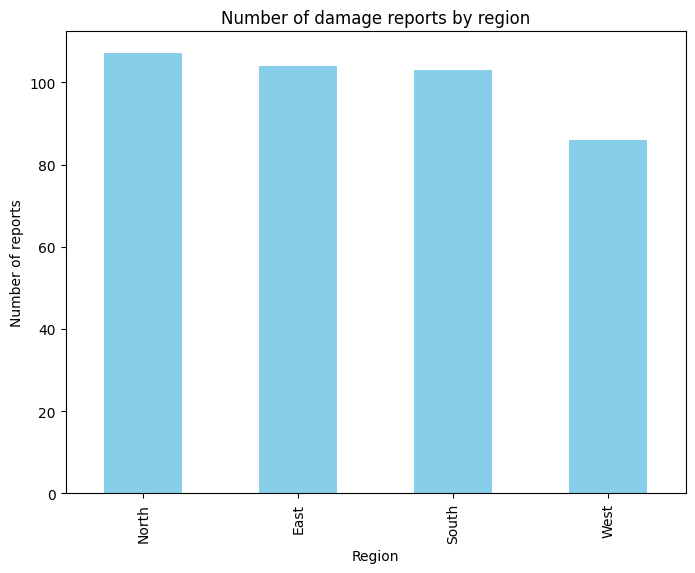

In [ ]:
# Group the data by region and count the damage reports
damage_per_region = natural_damage_df['Region'].value_counts()

# Create the bar chart
plt.figure(figsize=(8,6))
damage_per_region.plot(kind='bar', color='skyblue')
plt.title('Number of damage reports by region')
plt.xlabel('Region')
plt.ylabel('Number of reports')
plt.show()

# Pie chart / Circular chart

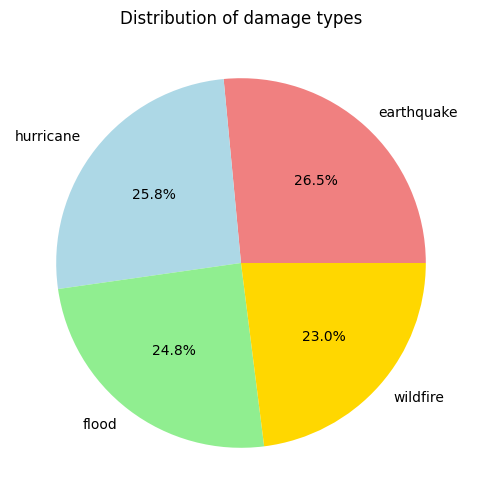

In [ ]:
# Group the data by damage type and count the occurrences
loss_per_claim_type = natural_damage_df['Claim_Type'].value_counts()

# Create the pie chart
plt.figure(figsize=(8,6))
loss_per_claim_type.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.title('Distribution of damage types')
plt.ylabel('')  # Removes the Y-axis label
plt.show()

# Statistical charts: histogram, box plot, and violin plot.
In addition to classic visualizations such as bar and pie charts, there are also statistical charts that help in understanding the distribution and dispersion of data. Among the most common are histograms, box plots, and violin plots.

# Histogram

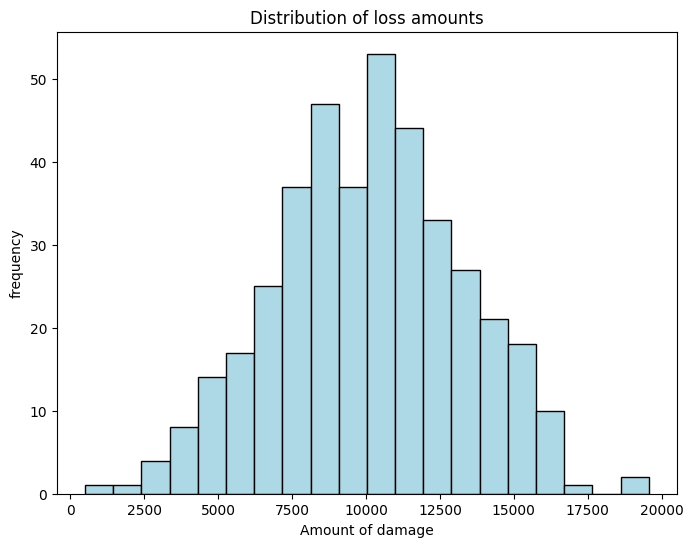

In [ ]:
# Create the histogram for the claim amount
plt.figure(figsize=(8,6))
plt.hist(natural_damage_df['Amount_of_Damage'], bins=20, color='lightblue', edgecolor='black')
plt.title('Distribution of loss amounts')
plt.xlabel('Amount of damage')
plt.ylabel('frequency')
plt.show()

# Box plot

<Figure size 800x600 with 0 Axes>

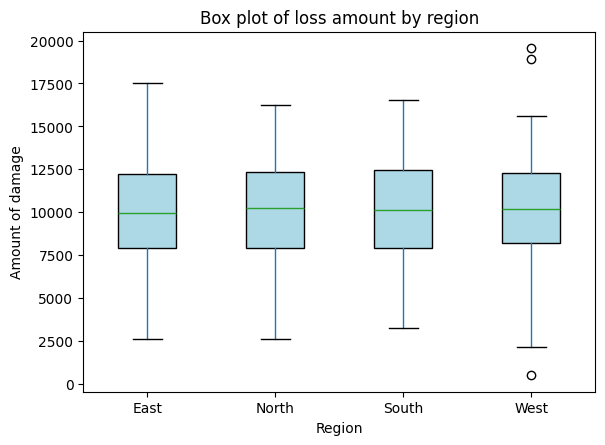

In [ ]:
# Create the box plot for claim amount by region
plt.figure(figsize=(8, 6))
natural_damage_df.boxplot(column='Amount_of_Damage', by='Region', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box plot of loss amount by region')
plt.suptitle('')  # Removes the additional title
plt.xlabel('Region')
plt.ylabel('Amount of damage')
plt.show()

# Scatter plot

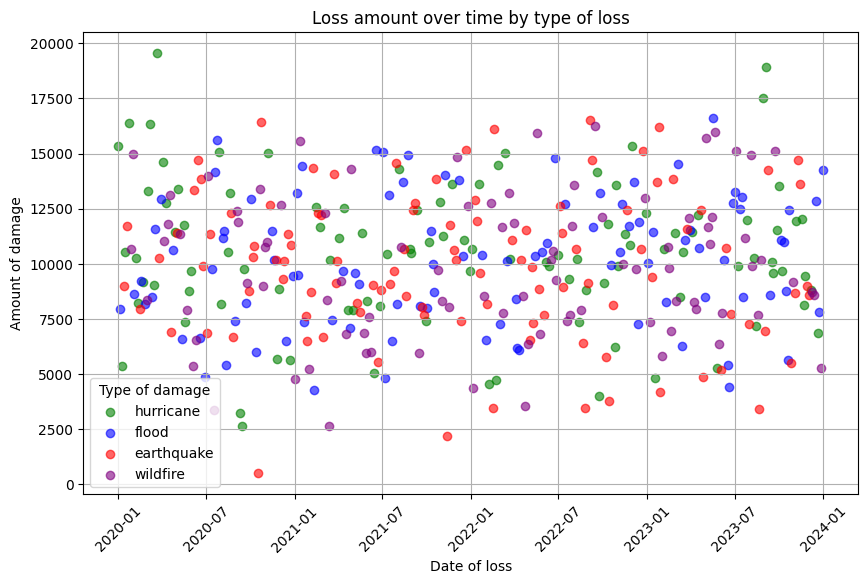

In [ ]:
# Colors for the different types of damage
colors = {'earthquake': 'red', 'flood': 'blue', 'hurricane': 'green', 'wildfire': 'purple'}

plt.figure(figsize=(10, 6))

# Scatter plot with different colors for each type of damage
for claim in natural_damage_df['Claim_Type'].unique():
  subset = natural_damage_df[natural_damage_df['Claim_Type']==claim]
  plt.scatter(subset['Date_of_loss'], subset['Amount_of_Damage'], c=colors[claim], label=claim, alpha=0.6)

# Adjust chart
plt.title('Loss amount over time by type of loss')
plt.xlabel('Date of loss')
plt.ylabel('Amount of damage')
plt.legend(title='Type of damage')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Task: Create various charts using matplotlib.
You have now been introduced to the basics of matplotlib. Create the following plots for the provided dataset `natural_damage_df` to visualize various aspects of the data:

1. **Line chart**: Visualize the development of the loss amount over time, grouping the data by the different regions. Adjust the following elements:
  * Colors and line styles (e.g., dashed lines, thicker lines).
  * x- and y-axis labels (Axis Labels).
  * Title for the chart.
  * Move the legend to a suitable position.
  * Visually highlight a single line (e.g., the "North" region).